# Deep Deterministic Policy Gradient

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from ddpg.ddpg_parallel import ddpg_trainer



In [2]:
# pendulum parameters
pendulum_model_name = 'rail'
# rail pendulum
if pendulum_model_name == 'rail':
    mass = 0.06
    length = 0.1
    damping = 0.0004
    torque_limit = 0.02
    coulomb_fric = 0.0
# dfki pendulum
elif pendulum_model_name == 'dfki':  
    mass = 0.57288
    length = 0.5
    damping = 0.15
    torque_limit = 1.5
    coulomb_fric = 0.02
else:
    raise Exception(f"Pendulum model {pendulum_model_name} not implemented")

inertia = mass*length**2

gravity = 9.81

# environment parameters
dt = 0.05 # changed from 0.01
integrator = "runge_kutta"
max_steps = 200
reward_type = "combined_reward"
target = [np.pi, 0]
target_epsilon = [0.05, 0.05] # Changed from 0.05
random_init = "everywhere"

# training parameters
n_episodes = 100
batch_size = 64*4*3
validate_every = 10 # changed from 20
validation_reps = 10
validation_limit = 0 # changed from -1800
train_every_steps = 1 # changed from 1
state_representation = 3
replay_buffer_size = 1000 # changed from 50000
actor = None  # use default agent
critic = None  # use default critic
discount = 0.99
actor_lr = 0.0005 # changed from 0.0005 
critic_lr = 0.001 # Changed from 0.001
tau = 0.005 # changed from 0.005

In [3]:
save_dir = "log_data/ddpg_training"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)



trainer = ddpg_trainer(batch_size=batch_size,
                       validate_every=validate_every,
                       validation_reps=validation_reps,
                       train_every_steps=train_every_steps)

trainer.init_pendulum(mass=mass,
                      length=length,
                      inertia=inertia,
                      damping=damping,
                      coulomb_friction=coulomb_fric,
                      gravity=gravity,
                      torque_limit=torque_limit)

trainer.init_environment(dt=dt,
                         integrator=integrator,
                         max_steps=max_steps,
                         reward_type=reward_type,
                         state_representation=state_representation,
                         validation_limit=validation_limit,
                         target=target,
                         state_target_epsilon=target_epsilon,
                         random_init=random_init)

trainer.init_agent(replay_buffer_size=replay_buffer_size,
                   actor=actor,
                   critic=critic,
                   discount=discount,
                   actor_lr=actor_lr,
                   critic_lr=critic_lr,
                   tau=tau)

rewards, actor_losses, critic_losses = trainer.train(n_episodes=n_episodes,
                                                     verbose=True)

trainer.save(save_dir)

/opt/homebrew/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 3)]               0         
                                                                 
 dense (Dense)               (None, 256)               1024      
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dense_2 (Dense)             (None, 1)                 257       
                                                                 
 tf.math.multiply (TFOpLambd  (None, 1)                0         
 a)                                                              
                                                                 
Total params: 67,073
Trainable params: 67,073
Non-trainable params: 0
_________________________________________________________

/opt/homebrew/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/opt/homebrew/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/opt/homebrew/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/opt/homebrew/lib/python3.10/site-packages/gym/spaces/box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")
/opt/homebrew/lib/python3.10/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend 

None
Episode: 0, Steps: 199, Reward: [-2000.0, -2000.0, -1925.71, -1939.05]
, Actor Loss: 0.0, Critic Loss: 0.0, Final State: [0.17791264 0.01013706 0.06178427 0.064009  ], Success: False
Episode: 1, Steps: 199, Reward: [-1994.46, -2000.0, -1874.26, -1991.28]
, Actor Loss: 0.0, Critic Loss: 0.0, Final State: [-0.0058661  -0.02415469 -0.09488002  0.06106433], Success: False
Episode: 2, Steps: 199, Reward: [-1971.05, -1970.64, -2000.0, -1927.6]
, Actor Loss: 0.0, Critic Loss: 0.0, Final State: [ 0.15777822 -0.05868104 -0.1176949  -0.11405525], Success: False
Episode: 3, Steps: 199, Reward: [-1913.12, -1993.62, -1994.83, -1961.09]
, Actor Loss: 0.0, Critic Loss: 0.0, Final State: [ 0.02751841 -0.13395706 -0.04615407 -0.12290861], Success: False
Episode: 4, Steps: 199, Reward: [-1898.79, -2000.0, -2000.0, -1991.71]
, Actor Loss: 0.0, Critic Loss: 0.0, Final State: [-0.15287763 -0.07287116 -0.0226202  -0.24880226], Success: False
Episode: 5, Steps: 199, Reward: [-1993.53, -1854.41, -2000.0,

INFO:tensorflow:Assets written to: log_data/ddpg_training/actor/assets


INFO:tensorflow:Assets written to: log_data/ddpg_training/actor/assets


INFO:tensorflow:Assets written to: log_data/ddpg_training/critic/assets


INFO:tensorflow:Assets written to: log_data/ddpg_training/critic/assets


In [4]:
print(trainer.replay_buffer.size)

80000


In [5]:
# plotting
MA_WINDOW = 10
ma_rewards = np.convolve(rewards, np.ones(MA_WINDOW)/MA_WINDOW, mode='valid')
episodes = np.arange(0, len(rewards))
ma_episodes = np.arange(len(rewards)-len(ma_rewards), len(rewards))

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Reward, per episode and moving average
ax[0].plot(episodes, rewards, '-g', label='reward')
ax[0].plot(ma_episodes, ma_rewards, '-b', label='mov. avg.')
ax[0].set_xlabel('Episode')
ax[0].set_ylabel('Reward')
ax[0].legend()

ax[1].plot(actor_losses, '-r', label='actor loss')
ax[1].plot(critic_losses, '-o', label='critic loss')
ax[1].set_xlabel('Episode')
ax[1].set_ylabel('Loss')
ax[1].legend()
plt.show()

ValueError: object too deep for desired array

In [4]:
from pendulum_plant.pendulum_plant import PendulumPlant
from pendulum_plant.simulation import Simulator
from ddpg.ddpg_controller import ddpg_controller

# Simulation using trained model

Final torque: 0.01999819092452526


2025-07-03 11:16:54.961683: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2025-07-03 11:16:54.987998: W tensorflow/c/c_api.cc:300] Operation '{name:'AssignVariableOp' id:65 op device:{requested: '/device:CPU:0', assigned: ''} def:{{{node AssignVariableOp}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false, _device="/device:CPU:0"](bias, Identity)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.
/opt/homebrew/lib/python3.10/site-packages/keras/engine/training_v1.py:2359: UserWarning: `Model.state_updates` will be removed in a future version. This property should not be used in TensorFlow 2.0, as `updates` are applied automatically.
  updates=self.state_updates,
2025-07-03 11:16:55.001697: W tensorflow/c/c_api.cc:300] Operation '{name:'t

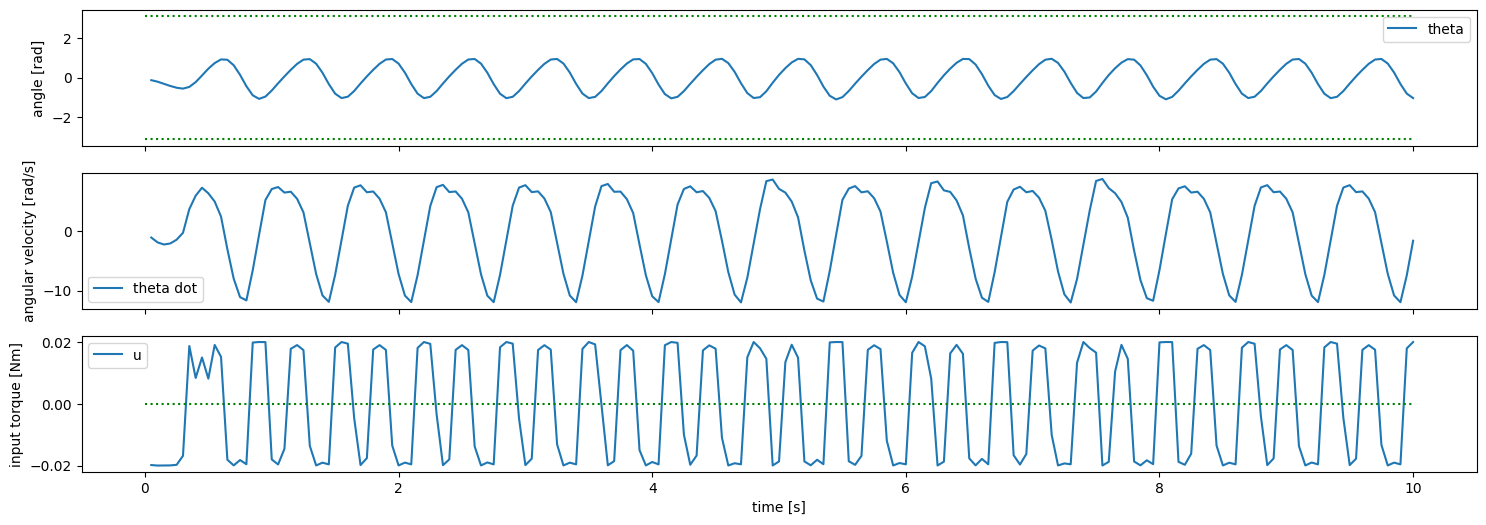

In [5]:



#mass = 0.57288
#length = 0.5
#damping = 0.15
#gravity = 9.81
#coulomb_fric = 0.02
#torque_limit = 1.5
#inertia = mass*length*length

dt = 0.05
t_final = 10.0

pendulum = PendulumPlant(mass=mass,
                         length=length,
                         damping=damping,
                         gravity=gravity,
                         coulomb_fric=coulomb_fric,
                         inertia=inertia,
                         torque_limit=torque_limit)


#model_path = "data_models/ddpg_model/actor"
model_path = "log_data/ddpg_training/actor"

controller = ddpg_controller(model_path=model_path,
                             torque_limit=torque_limit,
                             state_representation=3)


sim = Simulator(plant=pendulum)

T, X, U = sim.simulate(t0=0.0,
                                   x0=[-0.1, 0.0],
                                   tf=t_final,
                                   dt=dt,
                                   controller=controller,
                                   integrator="runge_kutta")

fig, ax = plt.subplots(3, 1, figsize=(18, 6), sharex="all")
print(f"Final torque: {U[-1]}")
ax[0].plot(T, np.asarray(X).T[0], label="theta")
ax[0].hlines(y=[-np.pi, np.pi], xmin=0, xmax = t_final, linestyles = ':', colors='g')
ax[0].set_ylabel("angle [rad]")
ax[0].legend(loc="best")
ax[1].plot(T, np.asarray(X).T[1], label="theta dot")
ax[1].set_ylabel("angular velocity [rad/s]")
ax[1].legend(loc="best")
ax[2].plot(T, np.asarray(U).flatten(), label="u")
ax[2].set_xlabel("time [s]")
ax[2].set_ylabel("input torque [Nm]")
ax[2].hlines(y=0, xmin=0, xmax=t_final, linestyles = ':', colors='g')
ax[2].legend(loc="best")
plt.show()


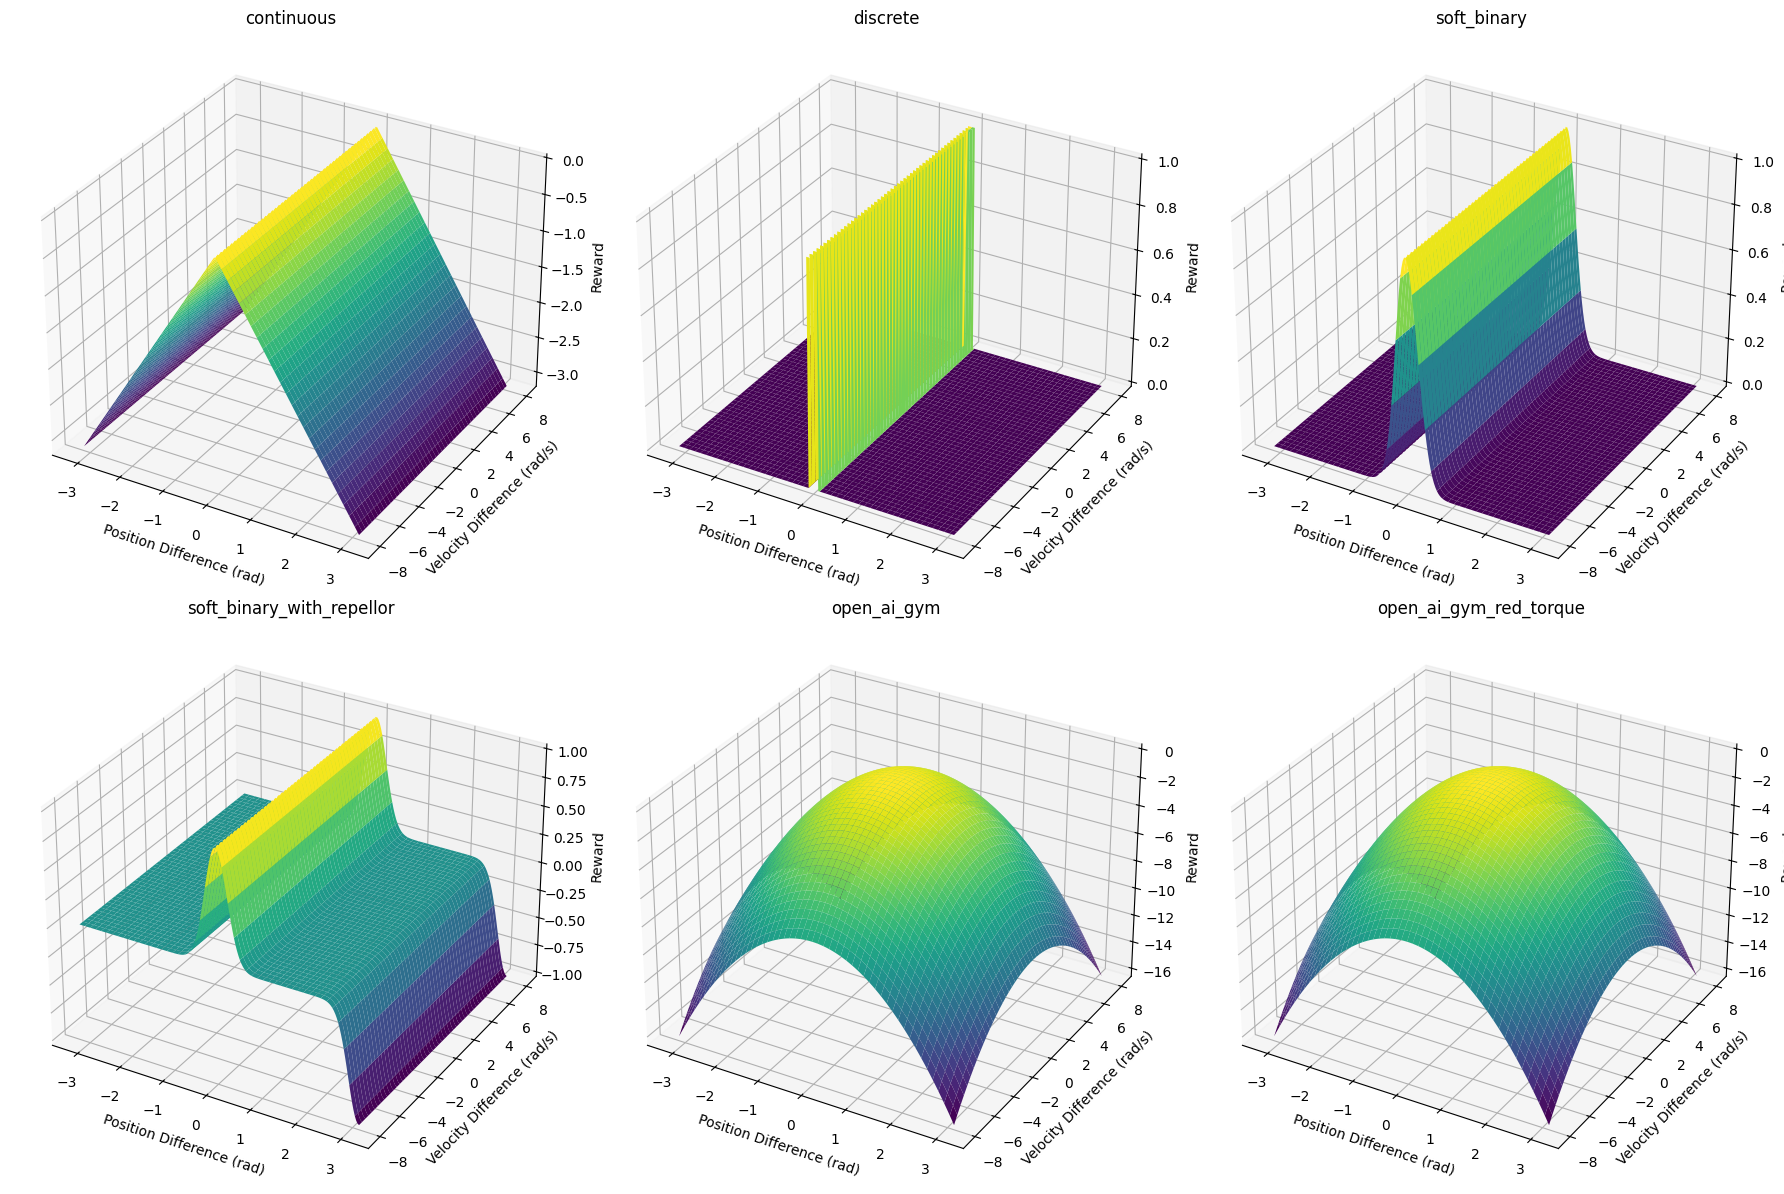

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Reward function definitions
def reward_continuous(pos_diff, vel_diff, action=0.0):
    return -np.abs(pos_diff)

def reward_discrete(pos_diff, vel_diff, action=0.0, epsilon=0.1):
    return (np.abs(pos_diff) < epsilon).astype(float)

def reward_soft_binary(pos_diff, vel_diff, action=0.0):
    return np.exp(-pos_diff**2 / (2 * 0.25**2))

def reward_soft_binary_with_repellor(pos_diff, vel_diff, action=0.0):
    attractor = np.exp(-pos_diff**2 / (2 * 0.25**2))
    repellor = np.exp(-np.abs(np.pi -pos_diff)**2 / (2 * 0.25**2))  # assume repellor at 0
    return attractor - repellor

def reward_open_ai_gym(pos_diff, vel_diff, action=0.0):
    return -(pos_diff)**2 - 0.1 * (vel_diff)**2 - 0.001 * action**2

def reward_open_ai_gym_red_torque(pos_diff, vel_diff, action=0.0):
    return -(pos_diff)**2 - 0.1 * (vel_diff)**2 - 0.01 * action**2

# Set up grid
pos_range = np.linspace(-np.pi, np.pi, 200)
vel_range = np.linspace(-8.0, 8.0, 200)
pos_diff, vel_diff = np.meshgrid(pos_range, vel_range)

# Compute all rewards
rewards = {
    "continuous": reward_continuous(pos_diff, vel_diff),
    "discrete": reward_discrete(pos_diff, vel_diff),
    "soft_binary": reward_soft_binary(pos_diff, vel_diff),
    "soft_binary_with_repellor": reward_soft_binary_with_repellor(pos_diff, vel_diff),
    "open_ai_gym": reward_open_ai_gym(pos_diff, vel_diff),
    "open_ai_gym_red_torque": reward_open_ai_gym_red_torque(pos_diff, vel_diff),
}

# Plot all in subplots
fig = plt.figure(figsize=(18, 12))
for i, (name, reward_grid) in enumerate(rewards.items(), 1):
    ax = fig.add_subplot(2, 3, i, projection='3d')
    ax.plot_surface(pos_diff, vel_diff, reward_grid, cmap='viridis')
    ax.set_title(name)
    ax.set_xlabel('Position Difference (rad)')
    ax.set_ylabel('Velocity Difference (rad/s)')
    ax.set_zlabel('Reward')

plt.tight_layout()
plt.show()


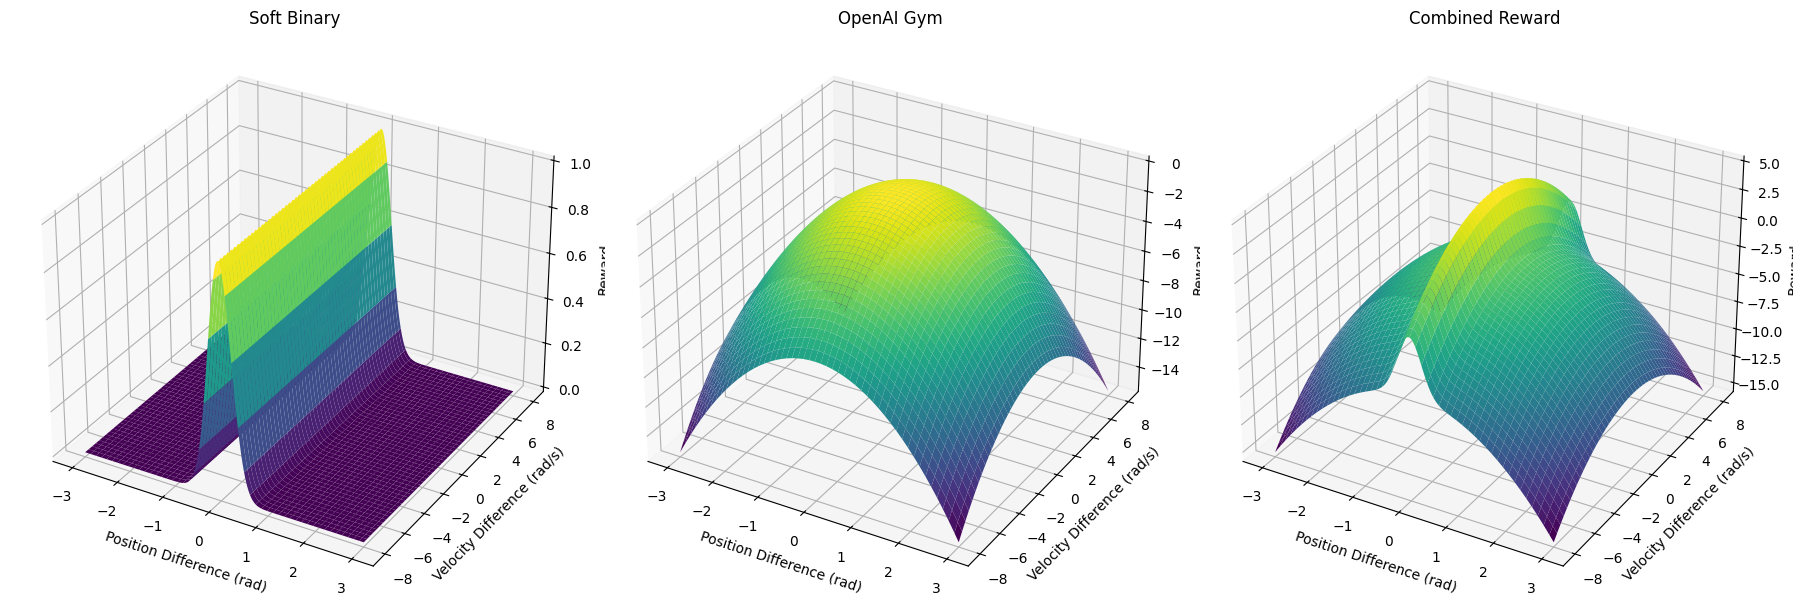

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Define reward functions
def soft_binary(pos_diff, vel_diff, action=0.0):
    return np.exp(-pos_diff**2 / (2 * 0.25**2))

def open_ai_gym(pos_diff, vel_diff, action=0.0):
    return (-(pos_diff)**2.0 - 0.1*(vel_diff)**2.0 - 0.001*action**2.0)

def combined_reward(pos_diff, vel_diff, action=0.0):
    return open_ai_gym(pos_diff, vel_diff, action) + 5 * soft_binary(pos_diff, vel_diff, action)

def combined_reward2(pos_diff, vel_diff, action=0.0):
    rew = open_ai_gym(pos_diff, vel_diff, action) + 5 * soft_binary(pos_diff, vel_diff, action) + 10* (pos_diff<0.05) * (vel_diff<0.05)
    return rew

# Create a grid of position and velocity differences
pos_range = np.linspace(-3.0, 3.0, 200)
vel_range = np.linspace(-8.0, 8.0, 200)
pos_diff, vel_diff = np.meshgrid(pos_range, vel_range)

# Compute reward grids
soft_binary_grid = soft_binary(pos_diff, vel_diff)
open_ai_gym_grid = open_ai_gym(pos_diff, vel_diff)
combined_grid = combined_reward(pos_diff, vel_diff)
combined_grid2 = combined_reward2(pos_diff, vel_diff)

# Plot all three reward functions
fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={'projection': '3d'})

titles = ['Soft Binary', 'OpenAI Gym', 'Combined Reward']
grids = [soft_binary_grid, open_ai_gym_grid, combined_grid]

for ax, title, grid in zip(axes, titles, grids):
    ax.plot_surface(pos_diff, vel_diff, grid, cmap='viridis')
    ax.set_title(title)
    ax.set_xlabel("Position Difference (rad)")
    ax.set_ylabel("Velocity Difference (rad/s)")
    ax.set_zlabel("Reward")

plt.tight_layout()
plt.show()